In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ['TRANSFORMERS_CACHE'] = '/mount/arbeitsdaten/asr-2/vaethdk/resources/weights/llm'

In [2]:
from tqdm.auto import tqdm
from typing import List, Tuple
DEVICE = 'cuda:0'
import torch

/home/users2/vaethdk/.virtualenvs/cts_al/lib64/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# a = torch.zeros(100000,40000,device="cuda:0")

In [3]:
import sys
sys.path.append('../../..')
print(os.path.realpath("."))

/mount/arbeitsdaten41/projekte/asr-2/vaethdk/cts_activelearning/conversational-tree-search/generation/reimburse/llama3


In [4]:
import transformers
from transformers import AutoModelForCausalLM, pipeline, AutoTokenizer, set_seed
from data.dataset import ReimburseGraphDataset, DataAugmentationLevel, NodeType, DialogNode, Question

/home/users2/vaethdk/.virtualenvs/cts_al/lib64/python3.10/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [5]:
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

In [6]:
pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.float16},
    device='cuda:0'
)

Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.28it/s]


In [7]:
set_seed(42)

In [8]:
import re

def unique_lines(generated_text: str) -> List[str]:
    # NOTE: text should be formatted as numbered list
    unique = []
    unique_lower = set()
    for idx, line in enumerate(generated_text.split("<br>")):
        line_cleaned = line.strip()
        if not line_cleaned.lower() in unique_lower:
            unique.append(line_cleaned)
            unique_lower.add(line_cleaned.lower())

    return unique

### System:
{System}

### User:
{User}

### Assistant:
{Assistant}

In [45]:
system = """You are a helpful assistant creating a list of FAQ-style questions from given facts.
Only generate questions that can be answered by the given facts, without any external knowledge.
Remove some information, especially nouns and named entities, between generated questions.
Use casual language.
Output only the generated paraphrases, separating each paraphrase with a <br> tag."""
user = 'Generate 100 FAQ-style questions from the fact: "In the US, you are entitled to 30$ per day, minus any free meals which you choose to decline."'

messages = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user
    }
]

outputs = pipeline(
    messages,
    max_new_tokens=5120,
    # do_sample = False
    temperature=2.0
)
generated_text: str = outputs[0]["generated_text"][-1]['content']
del outputs

for line in generated_text.split("<br>"):
    print(line)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Can I expect free cash during travel in a US state?

If something is included free how about daily pay on tour stayovers?

In every USA state daily stipend can I count on this benefit always or what?

For guests, if meals aren't taken, how can I expect to end each visit?

Does that make me have to accept the whole meal or parts, to keep the free extra cash?

Should meal free day happen you're expected what from daily sum cash benefit as?

Is money extra from cash available each day, what I'll pay?

For states in the USA how am extra daily cash payments determined after meals?

When daily cost of the day free does it turn extra benefit, as how much cash to spend on each state tourist day at destination US travel food choice meal options and choices from food options meals free is given and then remaining?

What happens if on daily stay I receive free food will a part have to come for the full benefit money amount left, after daily money pay is deducted of this one type, meal only of sta

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.autonotebook import tqdm

In [61]:
system = """You are a helpful assistant creating a list of FAQ-style questions from given facts.
Only generate questions that can be answered by the given facts, without any external knowledge.
Remove some information, especially nouns and named entities, between generated questions.
Use casual language.
Output only the generated paraphrases, separating each paraphrase with a <br> tag."""
user = 'Generate 100 FAQ-style questions from the fact: "In the US, you are entitled to 30$ per day, minus any free meals which you choose to decline."'

messages = [
    {
        "role": "system",
        "content": system
    },
    {
        "role": "user",
        "content": user
    }
]

seeds = [42, 6412, 90124, 39112, 581]
results = {}

for seed in seeds:
    temperatures = [i*0.05 for i in range(41)]
    num_unique_samples = []

    for temperature in tqdm(temperatures):
        set_seed(seed) 
        # generate samples using the current temperature
        if temperature == 0:
            outputs = pipeline(
                messages,
                max_new_tokens=10000,
                do_sample = False
            )
        else:
            outputs = pipeline(
                messages,
                max_new_tokens=10000,
                temperature=temperature
            )
        generated_text: str = outputs[0]["generated_text"][-1]['content']
        del outputs

        unique = unique_lines(generated_text)
        num_unique_samples.append(len(unique))

    results[seed] = num_unique_samples

  0%|          | 0/41 [00:00<?, ?it/s]/home/users2/vaethdk/.virtualenvs/cts_al/lib64/python3.10/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/users2/vaethdk/.virtualenvs/cts_al/lib64/python3.10/site-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
100%|██████████| 41/41 [1:07:19<00:00, 98.53s/it] 


In [62]:
import json

results['temperatures'] = temperatures
with open("unique_sentences_per_seed.json", "w") as f:
    json.dump(results, f)

In [76]:
# TODO!!!! Plot sample avg. and standard deviation
print(num_unique_samples)

[100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 101, 100, 100, 101, 101, 101, 1, 1, 1, 1, 1, 10, 1, 10, 1, 1, 8, 14, 1, 1, 5, 2, 5, 14, 6, 3, 14, 8]


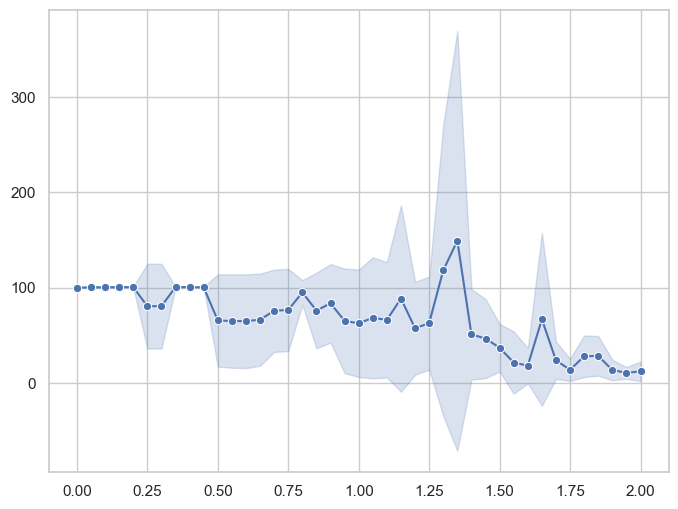

In [67]:
import pandas as pd
import numpy as np

x = temperatures + temperatures + temperatures + temperatures + temperatures
y = []
# del results['temperatures']
for seed in results:
    y.extend(results[seed])

data = {
    'temperature': x,
    'unique_sentences': y 
}

df = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
sns.lineplot(x='temperature', y='unique_sentences', data=df, marker='o', 
             estimator=np.mean, errorbar='sd')
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

## Generate Question Synonyms

In [66]:
from typing import List

def generate_prompt(system: str, user: str):
    return [
        {
            "role": "system",
            "content": system
        },
        {
            "role": "user",
            "content": user
        }
    ]

import re

def _split_numbered_list(input_string):
    # Regular expression to match the numbered items
    pattern = re.compile(r'(\d+\.\s+)(.*?)((?=\d+\.\s)|$)', re.DOTALL)
    matches = pattern.findall(input_string)
    
    # Extract the text for each item
    items = [match[1].strip() for match in matches]
    
    return items


def generate_output(prompt: List[str], temperature: float = 0.7, max_new_tokens: int = 7500) -> List[str]:
    outputs = pipeline(
        prompt,
        max_new_tokens=max_new_tokens,
        # do_sample = False
        temperature=temperature
    )
    generated_text: str = outputs[0]["generated_text"][-1]['content']

    # split outputs
    outputs = generated_text.split("<br>")
    if len(outputs) == 1: 
        # maybe the list was formatted as numbers
        print("Trying to split by number...")
        outputs = _split_numbered_list(generated_text)

    uniques = set()
    results = []
    duplicates = 0
  
    # collect outputs, and trim
    for result in outputs:
        cleaned = result.strip().strip("\n")
        if len(cleaned.split(" ")) < 3:
            print("SHORT:", cleaned)
        elif len(cleaned.split(" ")) > 100:
            number_split = _split_numbered_list(cleaned)
            if len(number_split) > 1:
                print("LONG, but number splittable")
                for number_line in number_split:
                    cleaned = number_line.strip().strip("\n")
                    cleaned = re.sub(r'^\d+\s*(\.?\s*)', '', cleaned)
                    if len(cleaned.split(" ")) < 3:
                        print("SHORT:", cleaned)
                    elif len(cleaned.split(" ")) > 100:
                        print("LONG", cleaned)
                    else:
                        if not cleaned.lower() in uniques:
                            results.append(cleaned.strip())
                            uniques.add(cleaned.lower())
            else:
                print("LONG:", cleaned)
        else:
            cleaned = re.sub(r'^\d+\s*(\.?\s*)', '', cleaned)
            if not cleaned.lower() in uniques:
                results.append(cleaned.strip())
                uniques.add(cleaned.lower())
    print(" - duplicates:", duplicates)
    return results

In [67]:
human_data_train = ReimburseGraphDataset('en/reimburse/train_graph.json', 'en/reimburse/train_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../../resources")

- not using synonyms
===== Dataset Statistics =====
- files:  en/reimburse/train_graph.json en/reimburse/train_answers.json
- synonyms: False
- depth: 20  - degree: 13
- answers: 81
- questions: 279
- loaded original data: True
- loaded generated data: False
- question limit: 0  - maximum loaded:  7
- answer limit: 0  - maximum loaded:  1


In [68]:
# check that we don't have any answer synonyms
for node in human_data_train.node_list:
    for question in node.questions:
        human_data_train.question_list.remove(question)
        del human_data_train.questions_by_key[question.key]
    node.questions.clear()
assert len(human_data_train.question_list) == 0
assert len(human_data_train.questions_by_key) == 0

# V1

In [31]:
from data.dataset import NodeType, Question
import time

set_seed(42)

system = """You are a helpful assistant creating a list of FAQ-style questions from given facts.
Only generate questions that can be answered by the given facts, without any external knowledge.
Remove some information, especially nouns and named entities, between generated questions.
Use casual language.
Output only the generated paraphrases, separating each paraphrase with a <br> tag."""

def user(answer_text: str, num_paraphrases: int) -> str:
    return f'Generate {num_paraphrases} FAQ-style questions from the fact: "{answer_text}"'

NUM_QUESTIONS = 100
TEMPERATURE = 0.7
MAX_NEW_TOKENS = 15000
generated_data = {}

for node in tqdm(human_data_train.nodes_by_type[NodeType.INFO]):
    prompt = generate_prompt(system=system, user=user(node.text, NUM_QUESTIONS))
    candidates = generate_output(prompt=prompt, temperature=TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS)
    for candidate in candidates:
        key = str(time.time()).replace(".", "")
        generated_data[key] = {
            "dialog_node_key": node.key,
            "key": key,
            "text": candidate,
        }

  1%|▏         | 1/80 [01:03<1:24:07, 63.89s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


SHORT: 
 - duplicates: 0


  2%|▎         | 2/80 [02:08<1:23:20, 64.11s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


SHORT: 
 - duplicates: 0


  4%|▍         | 3/80 [13:49<7:35:40, 355.07s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

 - duplicates: 0


 99%|█████████▉| 79/80 [5:13:52<01:54, 114.39s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


 - duplicates: 0


100%|██████████| 80/80 [5:14:51<00:00, 236.15s/it]

 - duplicates: 0


In [33]:
# TODO plot lengths of generated data per node (avg?)
1

1

In [32]:
import json

cleaned_data = {}
for key in generated_data:
    node = human_data_train.nodes_by_key[generated_data[key]['dialog_node_key']]
    cleaned_data[key] = generated_data[key]
    for i in range (1, NUM_QUESTIONS+1):
        cleaned_data[key]['text'] = cleaned_data[key]['text'].replace(f"{i}.", "").strip()
    cleaned_data[key]["node_text"] = node.text
    cleaned_data[key]["node_type"] = node.node_type.value

with open("../../../resources/en/reimburse/generated/llama3/train_questions_v1.json", "w") as f:
    json.dump(cleaned_data, f)

# DATA GENERATION V2: SHORTER QUESTIONS


In [13]:
from data.dataset import NodeType, Question
import time

set_seed(42)

system = """You are a helpful assistant creating a list of FAQ-style questions from given facts.
Only generate questions that can be answered by the given facts, without any external knowledge.
Remove some information, especially nouns and named entities, between generated questions.
Use casual language.
Prefer short questions.
Output only the generated paraphrases, separating each paraphrase with a <br> tag."""

def user(answer_text: str, num_paraphrases: int) -> str:
    return f'Generate {num_paraphrases} short FAQ-style questions from the fact: "{answer_text}"'

NUM_QUESTIONS = 10
TEMPERATURE = 0.7
MAX_NEW_TOKENS = 1024
generated_data = {}

for node in tqdm(human_data_train.nodes_by_type[NodeType.INFO]):
    prompt = generate_prompt(system=system, user=user(node.text, NUM_QUESTIONS))
    candidates = generate_output(prompt=prompt, temperature=TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS)
    for candidate in candidates:
        key = str(time.time()).replace(".", "")
        generated_data[key] = {
            "dialog_node_key": node.key,
            "key": key,
            "text": candidate,
        }

100%|██████████| 80/80 [11:34:35<00:00, 520.95s/it]  


In [14]:
import json

cleaned_data = {}
for key in generated_data:
    node = human_data_train.nodes_by_key[generated_data[key]['dialog_node_key']]
    cleaned_data[key] = generated_data[key]
    for i in range (1, NUM_QUESTIONS+1):
        cleaned_data[key]['text'] = cleaned_data[key]['text'].replace(f"{i}.", "").strip()
    cleaned_data[key]["node_text"] = node.text
    cleaned_data[key]["node_type"] = node.node_type.value

with open("resources/en/reimburse/generated/llama3/train_questions_v2.json", "w") as f:
    json.dump(cleaned_data, f)

# DATA GENERATION V3: SHORTER QUESTIONS + SPLIT NODE CONTEXT

1. Try to generate shorter questions (-> change prompt)
2. Try to generate more diverse questions
    1. Detect relevant sentences in node text via NER tool (also detects time, quantities, ...)
    2. Generate questions for whole node context, then for only relevant sentences / sub-sentences of node
    3. Choose amount of questions to be generated depending on amount of extracted NERs?

In [47]:
import stanza

In [46]:
import emoji
print(emoji.__version__)

2.1.0


In [48]:
torch.cuda.device_count()

1

In [49]:
#stanza.download(lang="en", model_dir=".models/")

2024-08-07 09:22:13 INFO: Downloaded file to .models/resources.json
2024-08-07 09:22:13 INFO: Downloading default packages for language: en (English) ...
2024-08-07 09:22:42 INFO: Downloaded file to .models/en/default.zip
2024-08-07 09:22:45 INFO: Finished downloading models and saved to .models/


In [50]:
nlp = stanza.Pipeline('en', processors='tokenize,ner', device="cuda:0")

2024-08-07 09:22:45 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2024-08-07 09:22:46 INFO: Downloaded file to /home/users2/vaethdk/stanza_resources/resources.json
2024-08-07 09:22:46 WARNING: Language en package default expects mwt, which has been added
2024-08-07 09:22:53 INFO: Loading these models for language: en (English):
| Processor | Package                   |
-----------------------------------------
| tokenize  | combined                  |
| mwt       | combined                  |
| ner       | ontonotes-ww-multi_charlm |

2024-08-07 09:22:53 INFO: Using device: cuda:0
2024-08-07 09:22:53 INFO: Loading: tokenize
2024-08-07 09:22:55 INFO: Loading: mwt
2024-08-07 09:22:55 INFO: Loading: ner
2024-08-07 09:22:56 INFO: Done loading processors!


In [16]:
print(doc.ents)

[{
  "text": "Barack Obama",
  "type": "PERSON",
  "start_char": 0,
  "end_char": 12
}, {
  "text": "Hawaii",
  "type": "GPE",
  "start_char": 25,
  "end_char": 31
}]


In [13]:
from statistics import mean

nodes_with_ner = 0
nodes_without_ner = 0
avg_node_ner = []

for node in tqdm(human_data_train.nodes_by_type[NodeType.INFO]):
    context = nlp(node.text)
    if len(context.ents) > 0:
        nodes_with_ner += 1
        avg_node_ner.append(len(context.ents))
    else:
        nodes_without_ner += 1

print("TOTAL INFO NODES", len(human_data_train.nodes_by_type[NodeType.INFO]))
print("NODES WITH NER", nodes_with_ner)
print("NODES WITHOUT NER", nodes_without_ner)
print("AVG NER PER NODE WITH NER", mean(avg_node_ner))

100%|██████████| 80/80 [00:04<00:00, 16.02it/s]

TOTAL INFO NODES 80
NODES WITH NER 33
NODES WITHOUT NER 47
AVG NER PER NODE WITH NER 2.090909090909091


In [14]:
avg_node_sentence_length = []

for node in human_data_train.nodes_by_type[NodeType.INFO]:
    avg_node_sentence_length.append(node.text.count("."))

print("MAX #SENTENCES PER NODE", max(avg_node_sentence_length))
print("AVG #SENTENCES PER NODE", mean(avg_node_sentence_length))

MAX #SENTENCES PER NODE 6
AVG #SENTENCES PER NODE 1.8


In [51]:
def extract_ner_sentences(node: DialogNode) -> List[Tuple[str, str]]:
    """
    Extract all sentences from node text that mention NER's.
    Returns them as a list of tuples, where each tuple contains
        1. the name of the entity
        2. the sentence containing that entity
    """
    results = []
    context = nlp(node.text)
    entities = context.ents
    for entity in entities:
        start_idx = entity.start_char
        end_idx = entity.end_char
        # expand start index to beginning of sentence
        while start_idx > 0 and node.text[start_idx-1] != ".":
            start_idx -= 1
        # expand end index to end of sentence
        while end_idx < len(node.text) and node.text[end_idx-1] != ".":
            end_idx += 1
        results.append((entity.text, node.text[start_idx:end_idx]))
    return results

In [52]:
# find a testing candidate
for node in human_data_train.nodes_by_type[NodeType.INFO]:
    results = extract_ner_sentences(node)
    if len(results) > 1:
        print(results)
        break

[('COVID-19', 'Please check the current COVID-19 travel warnings travel restrictions from the foreign ministry and the RKI.'), ('RKI', 'Please check the current COVID-19 travel warnings travel restrictions from the foreign ministry and the RKI.'), ('Department 4 (Administrative Department', ' In In extreme cases, authorization can be given by the leadership of Department 4 (Administrative Department).')]


In [53]:
print(node.text)

Please check the current COVID-19 travel warnings travel restrictions from the foreign ministry and the RKI. Business trips to high risk areas or virus variation areas are not generally not allowed. In In extreme cases, authorization can be given by the leadership of Department 4 (Administrative Department).


In [69]:
from data.dataset import NodeType, Question
import time


system = """You are a helpful assistant creating a list of FAQ-style questions from given facts.
Only generate questions that can be answered by the given facts, without any external knowledge.
Use casual language.
Output only the generated paraphrases, separating each paraphrase with a <br> tag."""

def user(answer_text: str, num_paraphrases: int) -> str:
    return f"Generate {num_paraphrases} short and diverse FAQ-style questions from the fact: '{answer_text}'"


NUM_QUESTIONS = 3
TEMPERATURE = 0.7
MAX_NEW_TOKENS = 1024
generated_data = {}


for entity, sentence in tqdm(extract_ner_sentences(node)):
    prompt = generate_prompt(system=system, user=user(sentence, NUM_QUESTIONS))
    candidates = generate_output(prompt=prompt, temperature=TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS)
    generated_data[entity] = candidates


0it [00:00, ?it/s]


In [70]:
import pprint
pprint.pprint(generated_data)

{}


In [15]:
from data.dataset import NodeType, Question
import time

system = """You are a helpful assistant creating a list of FAQ-style questions from given facts.
Only generate questions that can be answered by the given facts, without any external knowledge.
Use casual language.
Prefer short questions.
Output only the generated paraphrases, separating each paraphrase with a <br> tag."""

def user(answer_text: str, num_paraphrases: int) -> str:
    return f'Generate {num_paraphrases} short and diverse FAQ-style questions from the fact: "{answer_text}"'


NUM_QUESTIONS = 3
TEMPERATURE = 0.7
MAX_NEW_TOKENS = 1024

prompt = generate_prompt(system=system, user=user(node.text, NUM_QUESTIONS))
candidates = generate_output(prompt=prompt, temperature=TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS)
pprint.pprint(candidates)

KeyboardInterrupt: 

In [71]:
system = """You are a truthful assistant, generating diverse FAQ-style questions given some facts.
The generated questions should be answerable using the given facts only, without additional knowledge.
The questions should also be short and human-like.
Try to vary the amount of information between questions.
Use casual language.
Output only the generated paraphrases, separating each paraphrase with a <br> tag."""

def user(answer_text: str, num_paraphrases: int) -> str:
    return f'Generate {num_paraphrases} short and diverse FAQ-style questions from the fact: "{answer_text}"'

def user_ner(answer_text: str, ner: str, num_paraphrases: int) -> str:
    return f'Generate {num_paraphrases} short and diverse FAQ-style questions about the entity "{ner}" from the fact: "{answer_text}"'


NUM_QUESTIONS_PER_NER = 100
NUM_QUESTIONS_PER_NODE = 100
TEMPERATURE = 0.7
MAX_NEW_TOKENS = 10000
generated_data = {}

set_seed(42)

for node in tqdm(human_data_train.nodes_by_type[NodeType.INFO]):
    # use dict indexed by generated text to filter out duplicates
    all_generations = {}
    
    # extract NERs
    named_entities = extract_ner_sentences(node)

    # Generate questions with NER sentences only, make asking about NER a requirement
    for entity, sentence in named_entities:
        prompt = generate_prompt(system=system, user=user_ner(node.text, entity, NUM_QUESTIONS_PER_NER))
        candidates = generate_output(prompt=prompt, temperature=TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS)
        for candidate_idx, candidate in enumerate(candidates):
            key = str(time.time()).replace(".", "")
            cleaned_candidate = candidate.replace(f"{candidate_idx+1}.", "").strip()
            all_generations[cleaned_candidate] = {
                "context": "ner",
                "entity": entity,
                "dialog_node_key": node.key,
                "key": key,
                "text": cleaned_candidate
            }

    # Generate questions with whole context
    # num_node_level_questions = max(NUM_QUESTIONS_PER_SENTENCE, NUM_QUESTIONS_PER_NER - len(named_entities) * NUM_QUESTIONS_PER_SENTENCE)
    prompt = generate_prompt(system=system, user=user(node.text, NUM_QUESTIONS_PER_NODE))
    candidates = generate_output(prompt=prompt, temperature=TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS)
    for candidate_idx, candidate in enumerate(candidates):
        key = str(time.time()).replace(".", "")
        cleaned_candidate = candidate.replace(f"{candidate_idx+1}.", "").strip()
        all_generations[cleaned_candidate] = {
            "context": "node",
            "dialog_node_key": node.key,
            "key": key,
            "text": cleaned_candidate
        }
    
    # filter out duplicates
    uniques = set()
    for question_key in all_generations:
        question = all_generations[question_key]
        if question['text'].lower() in uniques:
            continue # skip duplicate
        else:
            uniques.add(question['text'].lower())
            generated_data[question['key']] = question

  0%|          | 0/80 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [ ]:
import json

human_data_test = ReimburseGraphDataset('en/reimburse/test_graph.json', 'en/reimburse/test_answers.json', False, augmentation=DataAugmentationLevel.NONE, resource_dir="../../../resources")

overlaps = 0
cleaned_data = {}
for key in generated_data:
    node = human_data_train.nodes_by_key[generated_data[key]['dialog_node_key']]
    test_node = human_data_test.nodes_by_key[generated_data[key]['dialog_node_key']]
    test_questions = set([q.text.strip().lower() for q in test_node.questions])
    if not generated_data[key]['text'].lower() in test_questions:
        # filter out overlap with test set!
        cleaned_data[key] = generated_data[key]
        cleaned_data[key]["node_text"] = node.text
        cleaned_data[key]["node_type"] = node.node_type.value
    else:
        overlaps += 1

print("REMOVED OVERLAP WITH TEST SET:", overlaps, "instances")

with open("resources/en/reimburse/generated/llama3/train_questions_v3.json", "w") as f:
    json.dump(cleaned_data, f)